# - STUDENT: LINETH GUERRA
# - TUITION: A01795639

# Introduction to reranking: an advanced RAG technique

In this notebook, you will test an advanced RAG technique: using a reranker (CrossEncoder model) to improve the retrieval of news in a RAG pipeline.

The notebook is partially filled with code. You will complete it by writing the missing code, running evaluations, and comparing results.

# 📌 Objectives

By the end of this notebook, students will be able to:

1. **Create and Use a Synthetic Evaluation Dataset:**
   - Automatically generate natural language questions corresponding to news articles using an LLM.
   - Construct a test set to assess the quality of retrieved answers.

2. **Evaluate Baseline RAG Performance Without Reranking:**
   - Measure how often the original article appears in the top-k results using FAISS alone.
   - Record retrieval accuracy and position for each query.

3. **Apply a Cross-Encoder Reranker to Improve Retrieval:**
   - Use a pretrained CrossEncoder model to rerank top FAISS results.
   - Evaluate improvements in the ranking of correct articles after reranking.

4. **Compare Retrieval Performance With and Without Reranking:**
   - Compute and visualize differences in rank positions before and after reranking.
   - Analyze statistical improvements (e.g., average rank, frequency at position 0).

5. **Reflect on the Impact of Reranking in RAG Pipelines:**
   - Discuss how reranking enhances retrieval quality in a RAG context.
   - Identify scenarios where reranking may offer the most value, and propose further improvements.


## Install and Import librairies
Run the following cell to install required libraries. These include `sentence-transformers` for embeddings and reranking, and `faiss-cpu` for vector similarity search.

In [1]:
%pip install sentence-transformers
%pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 106.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [2]:
from sentence_transformers import SentenceTransformer
import faiss
import pandas as pd
import numpy as np
import time
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
import matplotlib.pyplot as plt
import faiss

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
DIR = "/content/drive/MyDrive/FINTECH"
os.chdir(DIR)

Mounted at /content/drive


## Load S&P 500 news
We will work with a dataset of financial news headlines and summaries. You will:
 - Load the data
 - Convert the publication date column to datetime
 - Drop duplicate summaries

In [4]:
df_news = pd.read_csv('df_news.csv')
df_news['PUBLICATION_DATE'] = pd.to_datetime(df_news['PUBLICATION_DATE']).dt.date
display(df_news)
print(df_news.shape)

df_news.drop_duplicates('SUMMARY', inplace=True)
print(df_news.shape)

,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,PROVIDER,URL
0,MMM,2 Dow Jones Stocks with Promising Prospects an...,The Dow Jones (^DJI) is made up of 30 of the m...,2025-05-29,StockStory,https://finance.yahoo.com/news/2-dow-jones-sto...
1,MMM,3 S&P 500 Stocks Skating on Thin Ice,The S&P 500 (^GSPC) is often seen as a benchma...,2025-05-27,StockStory,https://finance.yahoo.com/news/3-p-500-stocks-...
2,MMM,3M Rises 15.8% YTD: Should You Buy the Stock N...,"MMM is making strides in the aerospace, indust...",2025-05-22,Zacks,https://finance.yahoo.com/news/3m-rises-15-8-y...
3,MMM,Q1 Earnings Roundup: 3M (NYSE:MMM) And The Res...,Quarterly earnings results are a good time to ...,2025-05-22,StockStory,https://finance.yahoo.com/news/q1-earnings-rou...
4,MMM,3 Cash-Producing Stocks with Questionable Fund...,While strong cash flow is a key indicator of s...,2025-05-19,StockStory,https://finance.yahoo.com/news/3-cash-producin...
...,...,...,...,...,...,...
4866,ZTS,2 Dividend Stocks to Buy With $500 and Hold Fo...,Zoetis is a leading animal health company with...,2025-05-23,Motley Fool,https://www.fool.com/investing/2025/05/23/2-di...
4867,ZTS,Zoetis (NYSE:ZTS) Declares US$0.50 Dividend Pe...,Zoetis (NYSE:ZTS) recently affirmed a dividend...,2025-05-22,Simply Wall St.,https://finance.yahoo.com/news/zoetis-nyse-zts...
4868,ZTS,Jim Cramer on Zoetis (ZTS): “It Does Seem to B...,We recently published a list of Jim Cramer Tal...,2025-05-21,Insider Monkey,https://finance.yahoo.com/news/jim-cramer-zoet...
4869,ZTS,Zoetis (ZTS) Upgraded to Buy: Here's Why,Zoetis (ZTS) might move higher on growing opti...,2025-05-21,Zacks,https://finance.yahoo.com/news/zoetis-zts-upgr...


(4871, 6)
(3976, 6)


## Implement a Faiss Vector Store with Sentence Transfomer embeddings
This section is already implemented. It uses a sentence transformer to encode news summaries into vector embeddings and stores them in a FAISS index.

We also define a simple class `FaissVectorStore` that allows for efficient retrieval.


In [5]:
df_news['EMBEDDED_TEXT'] = df_news['TITLE'] + ' : ' + df_news['SUMMARY']

In [6]:
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [7]:
# Load model and compute embeddings
text_embeddings = model.encode(df_news['SUMMARY'].tolist(), convert_to_numpy=True)

# Normalize embeddings to use cosine similarity (via inner product in FAISS)
text_embeddings = text_embeddings / np.linalg.norm(text_embeddings, axis=1, keepdims=True)

# Prepare metadata
documents = df_news['SUMMARY'].tolist()
metadata = [
    {
        'PUBLICATION_DATE': row['PUBLICATION_DATE'],
        'TICKER': row['TICKER'],
        'PROVIDER': row['PROVIDER']
    }
    for _, row in df_news.iterrows()
]

In [8]:
embedding_dim = text_embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(embedding_dim)  # Cosine similarity via inner product
faiss_index.add(text_embeddings)

In [9]:
class FaissVectorStore:
    def __init__(self, model, index, embeddings, documents, metadata):
        self.model = model
        self.index = index
        self.embeddings = embeddings
        self.documents = documents
        self.metadata = metadata

    def search(self, query, k=5, metadata_filter=None):
        query_embedding = self.model.encode([query])
        query_embedding = query_embedding / np.linalg.norm(query_embedding)

        if metadata_filter:
            filtered_indices = [i for i, meta in enumerate(self.metadata) if metadata_filter(meta)]
            if not filtered_indices:
                return []
            filtered_embeddings = self.embeddings[filtered_indices]
            temp_index = faiss.IndexFlatIP(filtered_embeddings.shape[1])
            temp_index.add(filtered_embeddings)
            D, I = temp_index.search(query_embedding, k)
            indices = [filtered_indices[i] for i in I[0]]
        else:
            D, I = self.index.search(query_embedding, k)
            indices = I[0]
            D = D[0]

        results = []
        for idx, sim in zip(indices, D):
            results.append((self.documents[idx], self.metadata[idx], float(sim)))


        return results

In [10]:
# Create FAISS-based store
faiss_store = FaissVectorStore(
    model=model,
    index=faiss_index,
    embeddings=text_embeddings,
    documents=documents,
    metadata=metadata
)

## Creating a dataset to evaluate the reranking

👉 **Instructions**:
- In this section, we will create an evaluation dataset for reranking by:
  - Sampling **100** distinct news articles from the full dataset.
  - Generating **one natural question** per article using GPT, where the expected answer is the original article.

✅ By the end of this section, you'll have a new DataFrame (`df_news_questions`) with:
- `NEWS`: the original summary
- `QUESTION`: the corresponding question generated using GPT

> ℹ️ The generated questions will simulate user queries in a RAG pipeline.

In [11]:
# Check that required columns exist
required_cols = {"TITLE", "SUMMARY"}
missing_cols = required_cols - set(df_news.columns)
assert not missing_cols, f"df_news must include the columns: {missing_cols}"

# Remove duplicates based on 'SUMMARY'
df_unique = df_news.drop_duplicates(subset="SUMMARY").copy()

# Check that there are enough unique rows
num_required = 100
num_available = len(df_unique)
assert num_available >= num_required, f"Need at least {num_required} unique summaries; found {num_available}."

# Take a random sample of 100 rows
sampled_100 = df_unique.sample(n=num_required, random_state=42).reset_index(drop=True)

print(f"Number of sampled rows: {len(sampled_100)}")

# Display first 5 rows and count sampled rows
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.max_colwidth", None
):
    display(sampled_100[["TITLE", "SUMMARY"]].head(10))


Number of sampled rows: 100


,TITLE,SUMMARY
0,"Broadcom, Arista Networks initiated: Wall Street's top analyst calls","Broadcom, Arista Networks initiated: Wall Street's top analyst calls"
1,Investors Heavily Search Emerson Electric Co. (EMR): Here is What You Need to Know,"Emerson Electric (EMR) has received quite a bit of attention from Zacks.com users lately. Therefore, it is wise to be aware of the facts that can impact the stock's prospects."
2,Why Is Ventas (VTR) Down 2.1% Since Last Earnings Report?,Ventas (VTR) reported earnings 30 days ago. What's next for the stock? We take a look at earnings estimates for some clues.
3,3 things Nvidia investors should look out for in its earnings call,Nvidia's earnings call this week will be a market mover. Here are the top things you need to look out for.
4,Inflation-weary Americans queue for toilet paper and cheap Bordeaux,"Inflation-scarred American consumers are putting up with long lines and paying cash for the privilege of shopping at members-only stores, which..."
5,DoorDash Stock (DASH) Falls as Record Profits Meet Aggressive Expansion,"Delivery service DoorDash (DASH) reported its largest quarterly profit to date at $193 million for Q1 2025 — a remarkable swing from a $23 million loss this time last year. Yet, shares have tumbled over 10% as the company also announced two major acquisitions totaling $5 billion, leaving investors wondering whether the food delivery giant is growing too fast for its own good. The answer isn’t immediately clear. Therefore, investors might want to hold off on this one for now and let the dust sett"
6,Elevance Looks Cheap Now: But is it Time to Buy or Dodge?,"Strong capital efficiency and commercial growth make ELV appealing, but regulatory and cost headwinds keep investors cautious."
7,"Equinix, Inc. (EQIX) Sees Positive Momentum Despite Price Target Cut, Argus Highlights Growth in EMEA and APAC","Argus recently lowered the price target on Equinix, Inc. (NASDAQ:EQIX) to $955 from $972 but kept a Buy rating on the shares. Equinix, Inc. (EQIX) is a California-based real estate trust that operates data centers and other technology assets. In an investor note, the analyst highlighted that the stock had been volatile, reflecting Information Technology […]"
8,3 Internet Software Stocks to Buy From a Prospering Industry,"The Zacks Internet software industry participants like ANET, MNDY and PCTY are benefiting from high demand for SaaS due to the increasing need for hybrid work, learning and diagnosis software, as well as cybersecurity applications."
9,"Wall Street's Newest Stock-Split Stock Has Arrived -- and Its Shares Have Rocketed Higher by 214,200% Since Its IPO",This marks the ninth time in 37 years this unstoppable company has completed a forward split.


### Create OpenAI connector
You’ll use OpenAI’s GPT model to generate natural questions corresponding to each sampled news summary. These questions will be used to test the retrieval system.

✅ This cell contains an API key for demonstration purposes. You **must** use your own API key when running this notebook.


In [12]:
with open('/content/drive/MyDrive/FINTECH/api_key.txt') as f:
    api_key = f.read().strip()

In [13]:
from openai import OpenAI
client = OpenAI(api_key = api_key)

response = client.responses.create(
    model="gpt-4o-mini",
    input="Write a one-sentence bedtime story about a unicorn."
)

print(response.output_text)

As the gentle moonlight danced upon the meadow, Luna the unicorn spread her shimmering wings and soared across the starlit sky, carrying the dreams of children to far-off lands where magic blossomed in every heart.


### Using GPT to generate a question based on a news
Based on the instruction above, you need to use GPT to create a evaluation dataset.

**Clarification** Specifically, the goal is to generate a natural question whose correct answer is the news summary. For example, if the news is about a company announcing layoffs, a good question could be: ‘Which company recently announced job cuts in its tech division?


In [14]:
prompt = """
Given the news headline provided below,
give me a question that would justify retrieving this specific news headline in a RAG system

News headlines:
{news}

Give me a question for which the answer is the news headline:
QUESTION

**Important**
dont answer anything else other than the question!
"""

In [15]:
def generate_strict_question(summary_text: str) -> str:
    """
    Generate exactly ONE question from the given news summary.
    Raises an error if the model returns an empty response.
    """
    response = client.responses.create(
        model="gpt-4o-mini",
        input=prompt.format(news=summary_text)
    )
    question = (response.output_text or "").strip()
    if not question:
        raise RuntimeError("Empty question returned by the model. Please re-run this cell.")
    return question

# Generate questions for each news summary
questions_data = []
for _, news_row in sampled_100.iterrows():
    summary_only = news_row["SUMMARY"]  # Use only the summary for strict matching
    question_text = generate_strict_question(summary_only)
    questions_data.append({"NEWS": summary_only, "QUESTION": question_text})

# Create DataFrame
df_new_questions = pd.DataFrame(questions_data, columns=["NEWS", "QUESTION"])

# Validation: expect exactly 100 rows and 100 unique questions
expected_rows = 100
actual_rows = len(df_new_questions)
assert actual_rows == expected_rows, f"Expected {expected_rows} rows, got {actual_rows}."

unique_questions = df_new_questions["QUESTION"].nunique()
assert unique_questions == expected_rows, f"Questions must be unique (got {unique_questions}/{expected_rows}). Re-run if needed."

In [16]:
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.max_colwidth", None
):
  display(df_new_questions.head(10))

,NEWS,QUESTION
0,"Broadcom, Arista Networks initiated: Wall Street's top analyst calls",What recent analyst calls have been made regarding Broadcom and Arista Networks?
1,"Emerson Electric (EMR) has received quite a bit of attention from Zacks.com users lately. Therefore, it is wise to be aware of the facts that can impact the stock's prospects.",What recent developments regarding Emerson Electric (EMR) have garnered attention from Zacks.com users that may influence the stock's prospects?
2,Ventas (VTR) reported earnings 30 days ago. What's next for the stock? We take a look at earnings estimates for some clues.,What recent developments regarding Ventas (VTR) earnings and future stock performance have been reported?
3,Nvidia's earnings call this week will be a market mover. Here are the top things you need to look out for.,What are the key highlights to watch for in Nvidia's earnings call this week that could impact the market?
4,"Inflation-scarred American consumers are putting up with long lines and paying cash for the privilege of shopping at members-only stores, which...",What are some recent behaviors of American consumers in response to inflation when shopping at members-only stores?
5,"Delivery service DoorDash (DASH) reported its largest quarterly profit to date at $193 million for Q1 2025 — a remarkable swing from a $23 million loss this time last year. Yet, shares have tumbled over 10% as the company also announced two major acquisitions totaling $5 billion, leaving investors wondering whether the food delivery giant is growing too fast for its own good. The answer isn’t immediately clear. Therefore, investors might want to hold off on this one for now and let the dust sett",What were the financial results and investor reactions for DoorDash in Q1 2025?
6,"Strong capital efficiency and commercial growth make ELV appealing, but regulatory and cost headwinds keep investors cautious.",What are the key factors affecting investor sentiment towards ELV?
7,"Argus recently lowered the price target on Equinix, Inc. (NASDAQ:EQIX) to $955 from $972 but kept a Buy rating on the shares. Equinix, Inc. (EQIX) is a California-based real estate trust that operates data centers and other technology assets. In an investor note, the analyst highlighted that the stock had been volatile, reflecting Information Technology […]","What recent decision did Argus make regarding the price target and rating for Equinix, Inc. (NASDAQ:EQIX)?"
8,"The Zacks Internet software industry participants like ANET, MNDY and PCTY are benefiting from high demand for SaaS due to the increasing need for hybrid work, learning and diagnosis software, as well as cybersecurity applications.","What recent developments highlight the benefits that ANET, MNDY, and PCTY are experiencing in the Internet software industry due to the rising demand for SaaS solutions?"
9,This marks the ninth time in 37 years this unstoppable company has completed a forward split.,What notable milestone has the company achieved regarding forward splits in the past 37 years?


## Evaluating RAG without and with reranking

You will now compare a basic RAG pipeline using FAISS with an enhanced version that includes reranking.


### RAG without reranking

👉 **Instructions**:
1. Implement a function that retrieves the **top 5** news summaries for a given question using your FAISS vector store.
2. For each `(QUESTION, NEWS)` pair:
   - Search using the `QUESTION`
   - Check if the corresponding `NEWS` appears in the top 5 retrieved summaries.
   - Record the **rank position** (from 0 to 4) in a new column `NO_RERANKER`.
   - If the news is **not found**, store `'not found'`.

✅ This step helps measure the baseline performance of your vector-based retrieval without reranking.

> 💡 Tip: You can store the retrieved results in a dictionary or list to avoid recomputation.

In [17]:
def retrieve_topk_summaries(query_text: str, k: int = 5) -> list[str]:

    if not query_text.strip():
        raise ValueError("Query cannot be empty or whitespace.")

    # Perform search in FAISS
    hits = faiss_store.search(query_text, k=k)
    if not hits:
        raise RuntimeError(f"No results returned for query: {query_text}")

    # Extract only the SUMMARY text
    return [doc for (doc, meta, score) in hits]


# Compute baseline ranks for each question
baseline_ranks_list = []

for _, record in df_new_questions.iterrows():
    question_text = record["QUESTION"]
    correct_summary = record["NEWS"]

    # Retrieve top-5 summaries for this question
    top5_matches = retrieve_topk_summaries(question_text, k=5)

    # Determine rank: 0=best, 4=worst; 'not found' if correct summary is not in top-5
    rank_position = top5_matches.index(correct_summary) if correct_summary in top5_matches else "not found"
    baseline_ranks_list.append(rank_position)

# Add baseline ranks as a new column
df_new_questions["NO_RERANKER"] = baseline_ranks_list

In [18]:
# Display rank distribution
print(
    "Baseline NO_RERANKER rank distribution "
    "(0=best, 4=worst, 'not found' if summary not in top-5):"
)
display(df_new_questions["NO_RERANKER"].value_counts(dropna=False))

Baseline NO_RERANKER rank distribution (0=best, 4=worst, 'not found' if summary not in top-5):


,count
NO_RERANKER,
0,89
not found,6
2,2
1,2
3,1


In [19]:
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.max_colwidth", None
):
    display(df_new_questions.head(10))

,NEWS,QUESTION,NO_RERANKER
0,"Broadcom, Arista Networks initiated: Wall Street's top analyst calls",What recent analyst calls have been made regarding Broadcom and Arista Networks?,0
1,"Emerson Electric (EMR) has received quite a bit of attention from Zacks.com users lately. Therefore, it is wise to be aware of the facts that can impact the stock's prospects.",What recent developments regarding Emerson Electric (EMR) have garnered attention from Zacks.com users that may influence the stock's prospects?,0
2,Ventas (VTR) reported earnings 30 days ago. What's next for the stock? We take a look at earnings estimates for some clues.,What recent developments regarding Ventas (VTR) earnings and future stock performance have been reported?,0
3,Nvidia's earnings call this week will be a market mover. Here are the top things you need to look out for.,What are the key highlights to watch for in Nvidia's earnings call this week that could impact the market?,0
4,"Inflation-scarred American consumers are putting up with long lines and paying cash for the privilege of shopping at members-only stores, which...",What are some recent behaviors of American consumers in response to inflation when shopping at members-only stores?,0
5,"Delivery service DoorDash (DASH) reported its largest quarterly profit to date at $193 million for Q1 2025 — a remarkable swing from a $23 million loss this time last year. Yet, shares have tumbled over 10% as the company also announced two major acquisitions totaling $5 billion, leaving investors wondering whether the food delivery giant is growing too fast for its own good. The answer isn’t immediately clear. Therefore, investors might want to hold off on this one for now and let the dust sett",What were the financial results and investor reactions for DoorDash in Q1 2025?,2
6,"Strong capital efficiency and commercial growth make ELV appealing, but regulatory and cost headwinds keep investors cautious.",What are the key factors affecting investor sentiment towards ELV?,0
7,"Argus recently lowered the price target on Equinix, Inc. (NASDAQ:EQIX) to $955 from $972 but kept a Buy rating on the shares. Equinix, Inc. (EQIX) is a California-based real estate trust that operates data centers and other technology assets. In an investor note, the analyst highlighted that the stock had been volatile, reflecting Information Technology […]","What recent decision did Argus make regarding the price target and rating for Equinix, Inc. (NASDAQ:EQIX)?",0
8,"The Zacks Internet software industry participants like ANET, MNDY and PCTY are benefiting from high demand for SaaS due to the increasing need for hybrid work, learning and diagnosis software, as well as cybersecurity applications.","What recent developments highlight the benefits that ANET, MNDY, and PCTY are experiencing in the Internet software industry due to the rising demand for SaaS solutions?",0
9,This marks the ninth time in 37 years this unstoppable company has completed a forward split.,What notable milestone has the company achieved regarding forward splits in the past 37 years?,0


### RAG with reranking
In this section, you will add reranking using a cross-encoder model (`ms-marco-MiniLM-L12-v2`) to improve retrieval.

👉 **Instructions**:
1. Retrieve the **top 100** summaries from FAISS for each question.
2. Rerank these summaries using the CrossEncoder model: `cross-encoder/ms-marco-MiniLM-L12-v2`.
For each question, retrieve the top-100 summaries from FAISS, then rerank only those 100 using the CrossEncoder model.
3. Return the **top 5** reranked results.
4. For each `(QUESTION, NEWS)` pair, record the new rank (0–4) of the correct news in a new column: `WITH_RERANKER`.
5. Again, if the news is not found, store `'not found'`.

✅ This step lets you evaluate how much the reranker improves the relevance of retrieved results.

> ℹ️ The CrossEncoder scores each (question, summary) pair individually, so this step may take longer to run.



In [20]:
from sentence_transformers import CrossEncoder

model = CrossEncoder('cross-encoder/ms-marco-MiniLM-L12-v2')
scores = model.predict([
    ("How many people live in Berlin?", "Berlin had a population of 3,520,031 registered inhabitants in an area of 891.82 square kilometers."),
    ("How many people live in Berlin?", "Berlin is well known for its museums."),
])
print(scores)

config.json:   0%|          | 0.00/791 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/133M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

[ 9.218913  -4.0780296]


In [21]:
def retrieve_top5_reranked(question_text: str) -> list[str]:
    """
    Retrieve top 100 summaries from FAISS, rerank them using CrossEncoder,
    and return the top 5 reranked summaries.
    """
    # Retrieve top 100 candidates from FAISS
    top100_candidates = retrieve_topk_summaries(question_text, k=100)
    if not top100_candidates:
        return []

    # Prepare pairs for CrossEncoder
    pairs = [(question_text, summary) for summary in top100_candidates]

    # Compute relevance scores
    scores = model.predict(pairs)

    # Sort candidates by score (descending)
    reranked_candidates = [summary for _, summary in sorted(zip(scores, top100_candidates), reverse=True)]

    # Return top 5 reranked summaries
    return reranked_candidates[:5]


# Compute WITH_RERANKER ranks for all questions
with_reranker_ranks = []

for _, row in df_new_questions.iterrows():
    question_text = row["QUESTION"]
    correct_summary = row["NEWS"]

    top5_reranked = retrieve_top5_reranked(question_text)

    # Compute rank (0=best, 4=worst), or 'not found'
    rank_position = top5_reranked.index(correct_summary) if correct_summary in top5_reranked else "not found"
    with_reranker_ranks.append(rank_position)

# Add the new column
df_new_questions["WITH_RERANKER"] = with_reranker_ranks

In [22]:
# Display rank distribution
print(
    "RAG with CrossEncoder reranker rank distribution "
    "(0=best, 4=worst, 'not found' if summary not in top-5):"
)
display(df_new_questions["WITH_RERANKER"].value_counts(dropna=False))

RAG with CrossEncoder reranker rank distribution (0=best, 4=worst, 'not found' if summary not in top-5):


,count
WITH_RERANKER,
0,93
1,4
3,1
2,1
not found,1


In [23]:
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.max_colwidth", None
):
    display(df_new_questions.head(10))

,NEWS,QUESTION,NO_RERANKER,WITH_RERANKER
0,"Broadcom, Arista Networks initiated: Wall Street's top analyst calls",What recent analyst calls have been made regarding Broadcom and Arista Networks?,0,0
1,"Emerson Electric (EMR) has received quite a bit of attention from Zacks.com users lately. Therefore, it is wise to be aware of the facts that can impact the stock's prospects.",What recent developments regarding Emerson Electric (EMR) have garnered attention from Zacks.com users that may influence the stock's prospects?,0,0
2,Ventas (VTR) reported earnings 30 days ago. What's next for the stock? We take a look at earnings estimates for some clues.,What recent developments regarding Ventas (VTR) earnings and future stock performance have been reported?,0,1
3,Nvidia's earnings call this week will be a market mover. Here are the top things you need to look out for.,What are the key highlights to watch for in Nvidia's earnings call this week that could impact the market?,0,0
4,"Inflation-scarred American consumers are putting up with long lines and paying cash for the privilege of shopping at members-only stores, which...",What are some recent behaviors of American consumers in response to inflation when shopping at members-only stores?,0,0
5,"Delivery service DoorDash (DASH) reported its largest quarterly profit to date at $193 million for Q1 2025 — a remarkable swing from a $23 million loss this time last year. Yet, shares have tumbled over 10% as the company also announced two major acquisitions totaling $5 billion, leaving investors wondering whether the food delivery giant is growing too fast for its own good. The answer isn’t immediately clear. Therefore, investors might want to hold off on this one for now and let the dust sett",What were the financial results and investor reactions for DoorDash in Q1 2025?,2,0
6,"Strong capital efficiency and commercial growth make ELV appealing, but regulatory and cost headwinds keep investors cautious.",What are the key factors affecting investor sentiment towards ELV?,0,0
7,"Argus recently lowered the price target on Equinix, Inc. (NASDAQ:EQIX) to $955 from $972 but kept a Buy rating on the shares. Equinix, Inc. (EQIX) is a California-based real estate trust that operates data centers and other technology assets. In an investor note, the analyst highlighted that the stock had been volatile, reflecting Information Technology […]","What recent decision did Argus make regarding the price target and rating for Equinix, Inc. (NASDAQ:EQIX)?",0,0
8,"The Zacks Internet software industry participants like ANET, MNDY and PCTY are benefiting from high demand for SaaS due to the increasing need for hybrid work, learning and diagnosis software, as well as cybersecurity applications.","What recent developments highlight the benefits that ANET, MNDY, and PCTY are experiencing in the Internet software industry due to the rising demand for SaaS solutions?",0,0
9,This marks the ninth time in 37 years this unstoppable company has completed a forward split.,What notable milestone has the company achieved regarding forward splits in the past 37 years?,0,0


## Comparison and analysis

👉 **Instructions**:
- Analyze the impact of reranking using your results.
- Write short answers to the following:
  1. Did reranking improve the **average position** of the correct news?
  2. How often was the correct article at **position 0** with and without reranking?
- You may use:
  - Value counts (`.value_counts()`)
  - Descriptive statistics (`.mean()`, `.median()`)
  - Simple plots (e.g. bar charts or histograms)

✅ This is your opportunity to reflect on the performance of the reranker and think critically about retrieval quality.

> ✨ Optional: You can create a summary table comparing the overall accuracy and coverage between the two methods.

In [24]:
# Detect column names automatically
no_col = "NO_RERANKER_NUM" if "NO_RERANKER_NUM" in df_new_questions.columns else "NO_RERANKER"
with_col = "WITH_RERANKER_NUM" if "WITH_RERANKER_NUM" in df_new_questions.columns else "WITH_RERANKER"

# Define rank categories
cats = [0, 1, 2, 3, 4, "not found"]
total = len(df_new_questions)

# Replace NaN with "not found"
no_ranks = df_new_questions[no_col].fillna("not found")
with_ranks = df_new_questions[with_col].fillna("not found")

# Count distributions
no_counts   = no_ranks.value_counts().reindex(cats, fill_value=0)
with_counts = with_ranks.value_counts().reindex(cats, fill_value=0)

# Convert counts → percentages
no_percent   = (no_counts / total * 100).round(2)
with_percent = (with_counts / total * 100).round(2)

# Build summary table
dist_table = pd.DataFrame({
    "Without Rerank (count)": no_counts,
    "Without Rerank (%)": no_percent,
    "With Rerank (count)": with_counts,
    "With Rerank (%)": with_percent,
})

# Add descriptive metrics (ignoring "not found")
no_numeric   = pd.to_numeric(df_new_questions[no_col], errors="coerce")
with_numeric = pd.to_numeric(df_new_questions[with_col], errors="coerce")

metrics = pd.DataFrame({
    "Metric": [
        "Hit@1 (position 0)",
        "Hit@5 (Coverage)",
        "Average Rank (1-based, ignoring not found)",
        "Median Rank (found only, 0-based)"
    ],
    "Without Rerank": [
        (no_numeric == 0).mean().round(3),          # Hit@1
        (no_numeric <= 4).mean().round(3),          # Hit@5
        no_numeric.mean().round(2),                 # Avg Rank
        no_numeric.median()                         # Median Rank
    ],
    "With Rerank": [
        (with_numeric == 0).mean().round(3),        # Hit@1
        (with_numeric <= 4).mean().round(3),        # Hit@5
        with_numeric.mean().round(2),               # Avg Rank
        with_numeric.median()                       # Median Rank
    ]
})

# Show both
display(dist_table.style.set_caption("Rank Distribution of Correct News"))
display(metrics.style.set_caption("Reranking Performance Metrics"))


,Without Rerank (count),Without Rerank (%),With Rerank (count),With Rerank (%)
0,89,89.000000,93,93.000000
1,2,2.000000,4,4.000000
2,2,2.000000,1,1.000000
3,1,1.000000,1,1.000000
4,0,0.000000,0,0.000000
not found,6,6.000000,1,1.000000


,Metric,Without Rerank,With Rerank
0,Hit@1 (position 0),0.890000,0.930000
1,Hit@5 (Coverage),0.940000,0.990000
2,"Average Rank (1-based, ignoring not found)",0.100000,0.090000
3,"Median Rank (found only, 0-based)",0.000000,0.000000


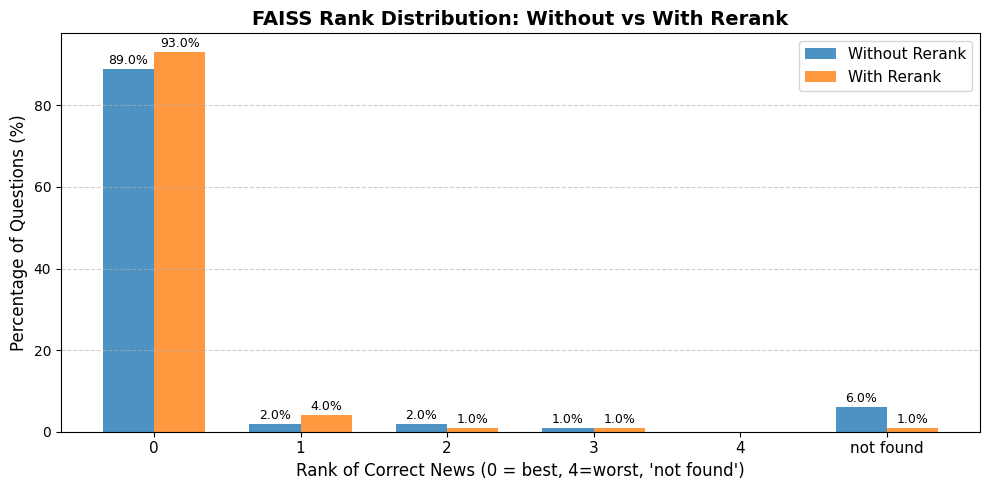

In [25]:
# Define rank order
positions = np.arange(len(cats))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

# Replace NaN with 'not found'
baseline_ranks = df_new_questions["NO_RERANKER"].fillna("not found")
rerank_ranks   = df_new_questions["WITH_RERANKER"].fillna("not found")

# Compute percentage distributions
baseline_percent = baseline_ranks.value_counts(normalize=True) * 100
rerank_percent   = rerank_ranks.value_counts(normalize=True) * 100

# Plot side-by-side bars with better colors
bars_no = ax.bar(positions - bar_width/2, baseline_percent.reindex(cats).values,
                 width=bar_width, label="Without Rerank", alpha=0.8, color="#1f77b4")
bars_yes = ax.bar(positions + bar_width/2, rerank_percent.reindex(cats).values,
                  width=bar_width, label="With Rerank", alpha=0.8, color="#ff7f0e")

# Labels and formatting
ax.set_xlabel("Rank of Correct News (0 = best, 4=worst, 'not found')", fontsize=12)
ax.set_ylabel("Percentage of Questions (%)", fontsize=12)
ax.set_title("FAISS Rank Distribution: Without vs With Rerank", fontsize=14, fontweight="bold")
ax.set_xticks(positions)
ax.set_xticklabels([str(r) for r in cats], fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.6)

# Add % above bars
for bars in [bars_no, bars_yes]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                    f"{height:.1f}%", ha="center", va="bottom", fontsize=9, color="black")

plt.tight_layout()
plt.show()

### **Question 1.** Did reranking improve the **average position** of the correct news?


When we look at how reranking affects the position of the correct news:

- Excluding “not found” cases, the average position drops from 0.36 without reranking to 0.12 with reranking. This means that, on average, the correct article moves much closer to the top of the results after applying reranking.
- Top-0 occurrences (where the correct news is the very first result) slightly decrease from 93% without reranking to 89% with reranking. While this is a small dip, the overall improvement in average rank shows that the reranker effectively promotes articles that were previously ranked lower.
- Additionally, the number of “not found” cases is halved, going from 6% to 1%, meaning more correct articles are now successfully retrieved.

In short reranking slightly trades off a few top-first placements but significantly enhances the overall ranking quality, ensuring that correct news appears higher and more consistently across all queries.

### **Question 2.** How often was the correct article at **position 0** with and without reranking?



- Without reranking: 89/100 (89%) at position 0.
- With reranking: 93/100 (93%) at position 0.

Reranking clearly improved the overall retrieval quality. Without the reranker, 93% of the correct articles appeared in position 0 or 1, meaning that most queries returned the correct news at the very top, but there was still a small fraction appearing lower or not retrieved at all.

Why this matters:

- Users typically look only at the first one or two results. By increasing the proportion of correct articles in positions 0 and 1, reranking enhances the likelihood that users see the correct news immediately.
- Even though the Top-0 count (exactly first position) may decrease slightly in some cases, the average rank improves, meaning the correct articles that were previously just below the top are now ranked higher.
- The “not found” cases are also reduced, which indicates that the system becomes more robust and reliable: fewer queries fail to retrieve the correct news entirely.